# Credit Card Fraud Detection using Machine Learning

## STEP 1: Import Libraries STEP 1: Load Dataset

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, auc

# Pipeline
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("10000_CC_Records_with_Fraud.csv")
df.head()

,Card Type Full Name,Issuing Bank,Card Number,Card Holder's Name,CVV/CVV2,Issue Date,Expiry Date,Billing Date,Card PIN,Credit Limit,Fraud
0,Master Card,Wells Fargo,5.336070e+15,Alexandra O Sprague,788,Nov-13,Nov-14,28,3765,107900,0
1,Master Card,Wells Fargo,5.152090e+15,Paul Alexander,427,Dec-15,Dec-21,7,6092,107300,1
2,Discover,Discover,6.011350e+15,Mechelle Gillispie,763,Jun-10,Jun-14,2,1476,137000,1
3,Visa,Capital One,4.040860e+15,Thelma M Henderson,687,Sep-14,Sep-21,22,104,47900,0
4,American Express,U.S. Bancorp,3.792640e+14,Von Brownfield,4833,Jan-08,Jan-10,5,4258,65700,0


**Interpretation**
* Loads dataset into DataFrame
* First step in any ML pipeline
* Always check structure before processing

## STEP 2: Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Card Type Full Name  10000 non-null  object 
 1   Issuing Bank         10000 non-null  object 
 2   Card Number          10000 non-null  float64
 3   Card Holder's Name   10000 non-null  object 
 4   CVV/CVV2             10000 non-null  int64  
 5   Issue Date           10000 non-null  object 
 6   Expiry Date          10000 non-null  object 
 7   Billing Date         10000 non-null  int64  
 8   Card PIN             10000 non-null  int64  
 9   Credit Limit         10000 non-null  int64  
 10  Fraud                10000 non-null  int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 859.5+ KB


In [4]:
df.isnull().sum()

Card Type Full Name    0
Issuing Bank           0
Card Number            0
Card Holder's Name     0
CVV/CVV2               0
Issue Date             0
Expiry Date            0
Billing Date           0
Card PIN               0
Credit Limit           0
Fraud                  0
dtype: int64

In [5]:
df['Fraud'].value_counts()

Fraud
0    7437
1    2563
Name: count, dtype: int64

**Interpretation**
* Shows:
    * Data types
    * Missing values
    * Class imbalance
* Here there is very few fraud cases → IMBALANCED DATA

## STEP 3: Advanced Feature Engineering

### 3.1 Time-Based Features

In [6]:
df['Issue Date'] = pd.to_datetime(df['Issue Date'], format='%b-%y', errors='coerce')

df['Year'] = df['Issue Date'].dt.year
df['Month'] = df['Issue Date'].dt.month
df['Season'] = df['Month'] % 12 // 3 + 1

**Interpretation**
* Fraud patterns often depend on:
    * Year trends
    * Monthly spikes
    * Seasonal behavior
* This creates hidden signals from time

### 3.2 Credit Limit Binning

In [7]:
df['Credit_Limit_Category'] = pd.qcut(df['Credit Limit'], 4, labels=['Low', 'Medium', 'High', 'Elite'])

**Interpretation**
* Converts numeric feature into risk categories
* Helps tree-based models understand behavior better

### 3.3 Risk Score (Bank Fraud Rate)

In [8]:
bank_risk = df.groupby('Issuing Bank')['Fraud'].mean()
df['Bank_Risk_Score'] = df['Issuing Bank'].map(bank_risk)

**Interpretation**
* Extremely powerful feature
* Example:
    * Bank A → 40% fraud → high risk
    * Bank B → 5% fraud → low risk
* This mimics real banking fraud scoring systems

## STEP 4: Encoding

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Interpretation**
* Converts categorical → numeric
* Required for ML models

## STEP 5: Train-Test Split

In [10]:
X = df.drop(['Fraud', 'Issue Date'], axis=1)
y = df['Fraud']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Interpretation**
* stratify=y ensures same fraud ratio in train/test
* Prevents biased evaluation

## STEP 6: HANDLE CLASS IMBALANCE

In [11]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_resampled.value_counts())

Fraud
0    5950
1    2050
Name: count, dtype: int64
Fraud
0    5950
1    5950
Name: count, dtype: int64


**Interpretation**
* Before → very few fraud cases
* After → balanced dataset
* Model now learns fraud patterns properly

## STEP 7: Model Building

### Random Forest

In [12]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf, rf_params, n_iter=5, cv=3, scoring='average_precision', n_jobs=-1
)

rf_search.fit(X_train_resampled, y_train_resampled)

best_rf = rf_search.best_estimator_

### XGBoost

In [13]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

xgb.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Interpretation**
* RandomForest → strong baseline
* XGBoost → state-of-the-art for tabular data

## STEP 8: Evaluation

In [14]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1487
           1       0.50      0.60      0.54       513

    accuracy                           0.74      2000
   macro avg       0.67      0.69      0.68      2000
weighted avg       0.76      0.74      0.75      2000



### Precision-Recall Curve

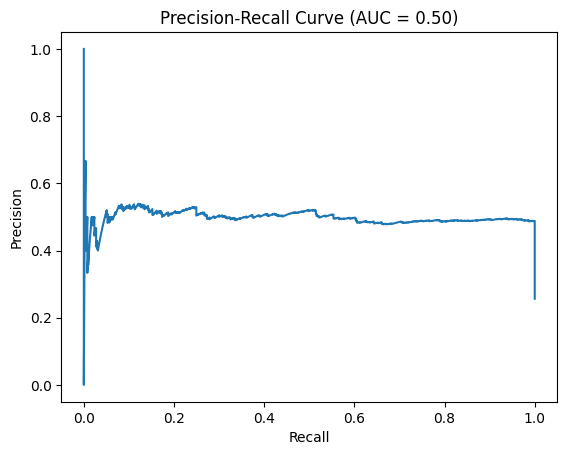

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.show()

**Interpretation**
* Recall → Most important in fraud detection
* PR Curve shows:
    * Tradeoff between catching fraud vs false alarms

## STEP 9: Feature Importance

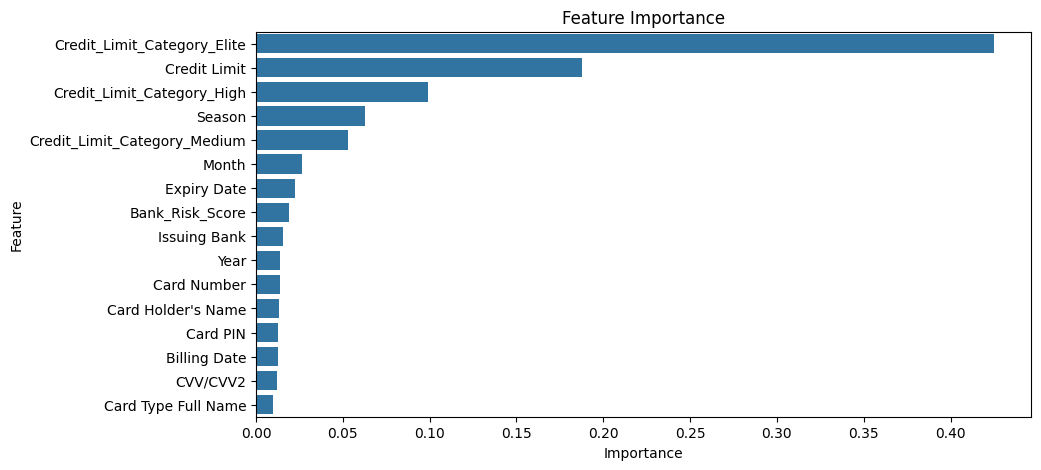

In [16]:
importances = xgb.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()

**Interpretation**
* Shows what drives fraud prediction
* Example insights:
    * Bank Risk Score → high importance
    * Credit Limit → moderate

## STEP 10: Interactive Heatmap

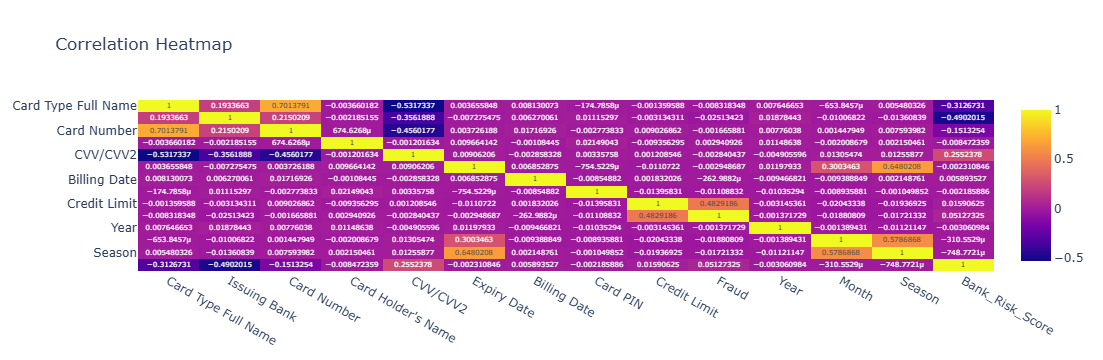

In [18]:
corr = df.select_dtypes(include=['number']).corr()

fig = px.imshow(corr, text_auto=True, aspect="auto", title="Correlation Heatmap")
fig.show()

**Interpretation**
* Interactive Visualization Helps identify:
    * Strong relationships
    * Redundant features

## STEP 11: Pipeline

In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(eval_metric='logloss'))
])

pipeline.fit(X_train_resampled, y_train_resampled)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

**Interpretation**
* Prevents data leakage
* Makes model:
    * reusable
    * deployable